## Phase 1 EDA - Credit Card Adoption

Goal: understand how the adoption rate (built in `src/features/build_adoption_label.py`, see `docs/decisions/001-service-a-product-choice.md` for why credit card is the target) varies **over time** and **across customer segments**. This is descriptive only - no modeling yet.

Findings here are meant to hint at which features are worth engineering in Phase 2, not to be a finished analysis.

Eligible population throughout: customer-months where the customer did **not** hold a credit card in month *t-1* (so they were actually able to adopt in month *t*).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
LABELS_PATH = PROCESSED_DIR / "adoption_labels_tjcr.parquet"
TRAIN_PATH = RAW_DIR / "train_ver2.csv"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 50)

## Load the adoption label

This is the file built by `src/features/build_adoption_label.py`. It has one
row per (customer, month), whether that customer held a card the prior month
(`prev_flag`), whether the label is even defined (`label_defined` - False for
rows with no prior-month record, e.g. new customers), and the derived
`adoption` flag.

In [2]:
labels = pd.read_parquet(LABELS_PATH)
labels["month"] = labels["fecha_dato"].dt.to_period("M")

print(f"shape: {labels.shape}")
print(f"memory: {labels.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

eligible = labels[labels["label_defined"] & (labels["prev_flag"] == 0)].copy()
print(f"eligible (non-holder in month t-1) rows: {len(eligible):,}")
print(f"overall adoption rate among eligible: {eligible['adoption'].mean():.4%}")

shape: (13647309, 7)
memory: 416.5 MB


eligible (non-holder in month t-1) rows: 12,111,689
overall adoption rate among eligible: 0.5707%


## Adoption rate over time

For each month, the denominator is the eligible population (non-holders as of
the prior month) and the numerator is how many of them adopted. Plotting the
rate rather than the raw count controls for the eligible pool's size changing
month to month.

         eligible_count  adoptions    rate
month                                     
2015-02          587315       3471  0.591%
2015-03          590745       5076  0.859%
2015-04          591796       4627  0.782%
2015-05          592148       4071  0.687%
2015-06          592856       4655  0.785%
2015-07          593700       4886  0.823%
2015-08          791202       4379  0.553%
2015-09          804976       4463  0.554%
2015-10          827442       4461  0.539%
2015-11          854119       4312  0.505%
2015-12          868027       4295  0.495%
2016-01          872744       3792  0.434%
2016-02          878996       3881  0.442%
2016-03          884682       4401  0.497%
2016-04          889085       4100  0.461%
2016-05          891856       4248  0.476%


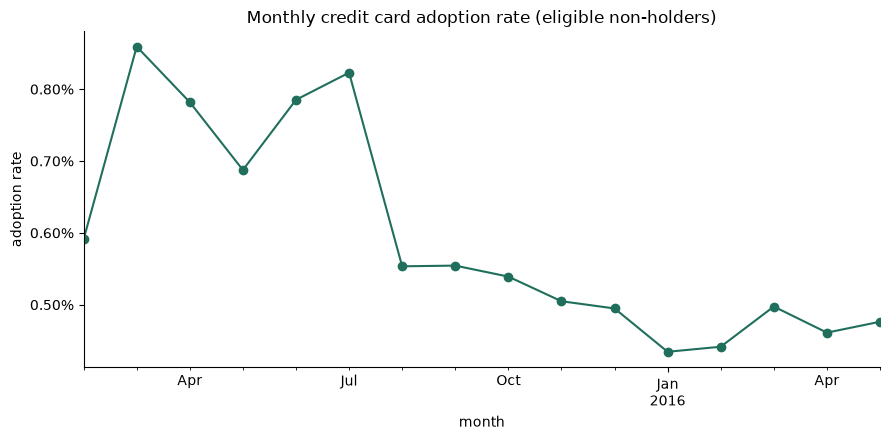

In [3]:
by_month = eligible.groupby("month").agg(
    eligible_count=("adoption", "size"),
    adoptions=("adoption", "sum"),
)
by_month["rate"] = by_month["adoptions"] / by_month["eligible_count"]
print(by_month.assign(rate=by_month["rate"].map("{:.3%}".format)))

fig, ax = plt.subplots()
by_month["rate"].plot(ax=ax, marker="o", color="#1f6f5c")
ax.set_ylabel("adoption rate")
ax.set_xlabel("month")
ax.set_title("Monthly credit card adoption rate (eligible non-holders)")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
plt.tight_layout()
plt.show()

## Adoption rate by customer segment

### Why we use month *t-1* attributes, not month *t*

To see whether adoption differs by age, tenure, income, etc., we need to
attach each customer's profile to their row in the label file. The easy-looking
move is to use the customer's profile **in the same month the label lives in**
(month *t*) - but that month is *after* the adoption already happened. A
customer who just got a credit card may look different in month *t* than they
did in month *t-1* (e.g. `ind_actividad_cliente`, the activity flag, could
change as a side effect of taking on a new product). Using month *t* profile
data to \"explain\" an event that already happened by month *t* risks **leakage**:
finding a fake pattern that's actually just a downstream consequence of the
event, not a cause available beforehand.

The fix: join each labeled row to that customer's profile as of month *t-1*
(before the adoption could have happened), using the same merge-key trick
(`ncodpers` + calendar month) already used to build the label itself. This
matters just as much later, for Phase 2 features - any feature has to be
known *before* the prediction month to be usable.

In [4]:
PROFILE_COLS = [
    "fecha_dato",
    "ncodpers",
    "age",
    "antiguedad",
    "renta",
    "segmento",
    "sexo",
    "ind_actividad_cliente",
    "canal_entrada",
]

# age / antiguedad are read as strings in the raw file: fixed-width, space
# padded (e.g. " 35", "     34"), and antiguedad uses the literal string
# "     NA" for missing instead of an empty field - so they need cleanup
# before they can be numeric.
profile = pd.read_csv(
    TRAIN_PATH,
    usecols=PROFILE_COLS,
    dtype={
        "ncodpers": "int32",
        "age": "str",
        "antiguedad": "str",
        "renta": "float32",
        "segmento": "category",
        "sexo": "category",
        "ind_actividad_cliente": "float32",
        "canal_entrada": "category",
    },
    parse_dates=["fecha_dato"],
)

profile["age"] = pd.to_numeric(
    profile["age"].str.strip(), errors="coerce"
).astype("float32")
profile["antiguedad"] = pd.to_numeric(
    profile["antiguedad"].str.strip().replace("NA", np.nan), errors="coerce"
).astype("float32")
profile["month"] = profile["fecha_dato"].dt.to_period("M")

print(f"profile shape: {profile.shape}")
print(f"profile memory: {profile.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
profile[["age", "antiguedad", "renta", "ind_actividad_cliente"]].describe()

profile shape: (13647309, 10)
profile memory: 520.6 MB


,age,antiguedad,renta,ind_actividad_cliente
count,1.361958e+07,1.361958e+07,1.085293e+07,1.361958e+07
mean,4.018151e+01,7.659197e+01,1.342542e+05,4.578106e-01
std,1.718509e+01,1.671807e+03,2.306202e+05,4.982169e-01
min,2.000000e+00,-9.999990e+05,1.202730e+03,0.000000e+00
25%,2.400000e+01,2.300000e+01,6.871098e+04,0.000000e+00
50%,3.900000e+01,5.000000e+01,1.018500e+05,0.000000e+00
75%,5.000000e+01,1.350000e+02,1.559560e+05,1.000000e+00
max,1.640000e+02,2.560000e+02,2.889440e+07,1.000000e+00


In [5]:
eligible["prev_month"] = eligible["month"] - 1

profile_lookup = profile.rename(columns={"month": "profile_month"})

eligible_seg = eligible.merge(
    profile_lookup.drop(columns=["fecha_dato"]),
    left_on=["ncodpers", "prev_month"],
    right_on=["ncodpers", "profile_month"],
    how="left",
)

matched = eligible_seg["profile_month"].notna().mean()
print(f"eligible rows matched to a t-1 profile: {matched:.2%}")
del profile, profile_lookup  # free memory, no longer needed

eligible rows matched to a t-1 profile: 100.00%


In [6]:
def adoption_rate_by(df, group_col, min_count=500):
    """Adoption rate and eligible count per group, dropping groups too small
    to trust the rate (avoids a rate of e.g. 1/2 = 50% from a 2-row group)."""
    g = df.groupby(group_col, observed=True)["adoption"].agg(["mean", "count"])
    g = g.rename(columns={"mean": "rate"})
    return g[g["count"] >= min_count].sort_index()


def print_rate(df, label=None):
    """Print a rate table with the rate column shown as a percentage, to
    match how the same numbers are formatted on the charts."""
    if label:
        print(f"{label}:")
    print(df.assign(rate=df["rate"].map("{:.3%}".format)))


def plot_rate_bar(rate_df, title, ax=None):
    ax = ax or plt.subplots()[1]
    rate_df["rate"].plot(kind="bar", ax=ax, color="#1f6f5c")
    ax.set_ylabel("adoption rate")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
    plt.tight_layout()
    return ax

### Age

              rate    count
age_bucket                 
(0, 20]     0.011%   538133
(20, 25]    0.029%  3155487
(25, 30]    0.181%  1153649
(30, 35]    0.629%   768933
(35, 40]    0.907%  1036549
(40, 45]    1.110%  1354215
(45, 50]    1.160%  1133372
(50, 60]    1.067%  1406224
(60, 70]    0.800%   750601
(70, 100]   0.335%   782509


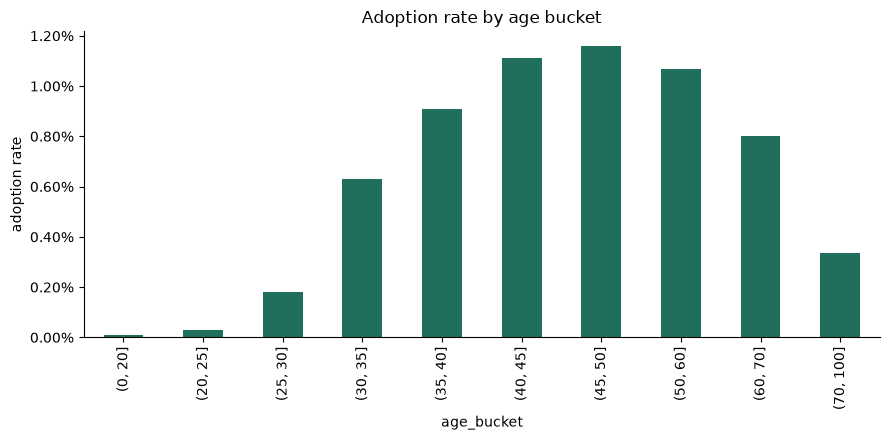

In [7]:
age_bins = [0, 20, 25, 30, 35, 40, 45, 50, 60, 70, 100]
eligible_seg["age_bucket"] = pd.cut(eligible_seg["age"], bins=age_bins)

rate_by_age = adoption_rate_by(eligible_seg, "age_bucket")
print_rate(rate_by_age)
plot_rate_bar(rate_by_age, "Adoption rate by age bucket")
plt.show()

### Tenure (antiguedad, months as a customer)

                 rate    count
tenure_bucket                 
(-1, 6]        0.113%   866253
(6, 12]        0.106%   942107
(12, 24]       0.208%  1600776
(24, 36]       0.254%  1397627
(36, 60]       0.288%  1930420
(60, 120]      0.744%  1997217
(120, 240]     1.184%  3321636
(240, 1000]    1.438%    35454


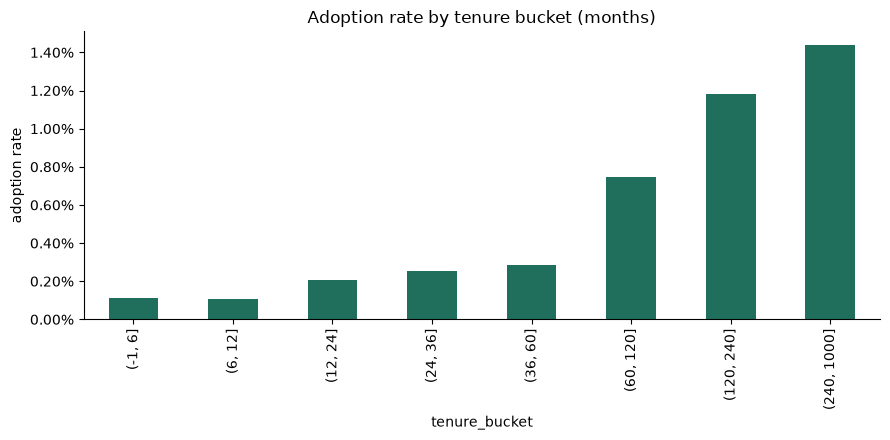

In [8]:
tenure_bins = [-1, 6, 12, 24, 36, 60, 120, 240, 1000]
eligible_seg["tenure_bucket"] = pd.cut(eligible_seg["antiguedad"], bins=tenure_bins)

rate_by_tenure = adoption_rate_by(eligible_seg, "tenure_bucket")
print_rate(rate_by_tenure)
plot_rate_bar(rate_by_tenure, "Adoption rate by tenure bucket (months)")
plt.show()

### Income (renta)

`renta` is ~20% missing (noted in the Phase 1 missingness scan) and heavily
right-skewed, so quantile-based bins (equal-sized groups) are used instead of
fixed-width bins - fixed-width bins would put almost everyone in one bucket
and leave the rest nearly empty.

                          rate    count
income_bucket                          
(999.999, 62000.0]      0.360%  1965419
(62000.0, 87000.0]      0.481%  1961814
(87000.0, 118000.0]     0.613%  1898071
(118000.0, 173000.0]    0.769%  1909143
(173000.0, 28894000.0]  0.879%  1906394


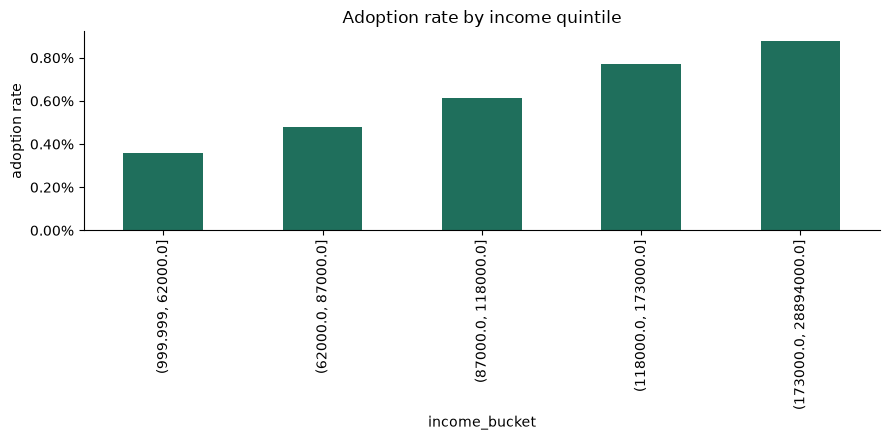

In [9]:
# round to the nearest 1,000 before binning purely for readable bin-edge
# labels on the chart (e.g. "(172,000, 28,894,000]" instead of 6 decimal places)
income_rounded = eligible_seg["renta"].round(-3)
eligible_seg["income_bucket"] = pd.qcut(income_rounded, q=5, duplicates="drop")

rate_by_income = adoption_rate_by(eligible_seg, "income_bucket")
print_rate(rate_by_income)
plot_rate_bar(rate_by_income, "Adoption rate by income quintile")
plt.show()

### Customer segment, sex, and activity index

segmento:
                      rate    count
segmento                           
01 - TOP            3.013%   417361
02 - PARTICULARES   0.748%  6968532
03 - UNIVERSITARIO  0.094%  4555910


sexo:
        rate    count
sexo                 
H     0.436%  5561111
V     0.687%  6530333
ind_actividad_cliente:


                         rate    count
ind_actividad_cliente                 
Inactive               0.026%  6821619
Active                 1.278%  5269890


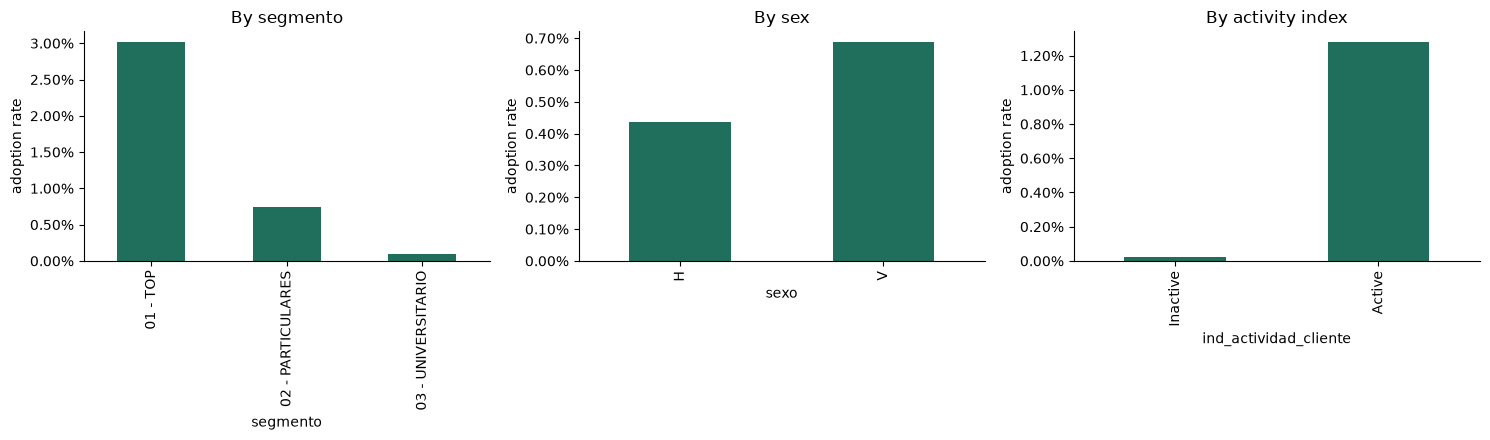

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

rate_by_segmento = adoption_rate_by(eligible_seg, "segmento")
print_rate(rate_by_segmento, "segmento")
plot_rate_bar(rate_by_segmento, "By segmento", ax=axes[0])

rate_by_sexo = adoption_rate_by(eligible_seg, "sexo")
print_rate(rate_by_sexo, "sexo")
plot_rate_bar(rate_by_sexo, "By sex", ax=axes[1])

# relabel 0.0/1.0 so the chart is readable without needing the printed table
rate_by_activity = adoption_rate_by(eligible_seg, "ind_actividad_cliente")
rate_by_activity = rate_by_activity.rename(index={0.0: "Inactive", 1.0: "Active"})
print_rate(rate_by_activity, "ind_actividad_cliente")
plot_rate_bar(rate_by_activity, "By activity index", ax=axes[2])

plt.tight_layout()
plt.show()

### Acquisition channel (canal_entrada)

Many channel codes have tiny counts, so this looks only at the top 15
channels by eligible volume.

                 rate    count
canal_entrada                 
KAS            1.368%    71110
KAT            1.127%  2772551
KAG            1.064%    64384
KFA            1.041%   355994
RED            1.012%    64992
KFC            0.835%  2717450
KAA            0.726%    58523
KAB            0.584%    55659
KAY            0.488%    60300
KHN            0.306%    97403
KHK            0.246%   220420
KHM            0.216%   149810
KHE            0.025%  3794690
KHD            0.025%   109242
KHQ            0.002%   514800


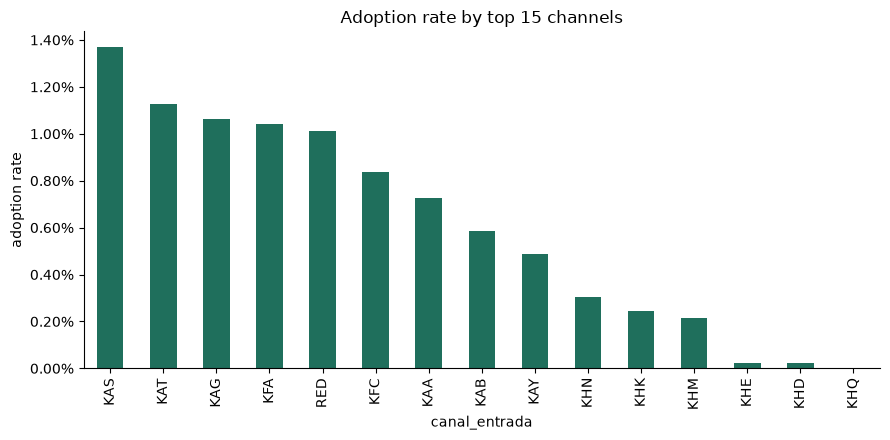

In [11]:
top_channels = eligible_seg["canal_entrada"].value_counts().head(15).index
channel_subset = eligible_seg[eligible_seg["canal_entrada"].isin(top_channels)]

rate_by_channel = adoption_rate_by(channel_subset, "canal_entrada")
rate_by_channel = rate_by_channel.sort_values("rate", ascending=False)
print_rate(rate_by_channel)
plot_rate_bar(rate_by_channel, "Adoption rate by top 15 channels")
plt.show()

## Findings summary

Eligible population: 12,111,689 customer-months (non-holders as of month t-1).
Overall adoption rate: 0.57%.

**Over time**: the rate roughly halved across the window, from ~0.79-0.86%
in the first half of 2015 down to ~0.43-0.50% by early-mid 2016, with no
strong seasonal pattern beyond a small bump each March. Also note the
eligible pool itself grew from ~587k to ~892k month over month - not just the
rate but the base is shifting, worth remembering before comparing early vs
late months directly.

**Age**: non-monotonic - an inverted U. Rate climbs from near 0% under 20 up
to a peak of ~1.1-1.2% in the 40-50 bracket, then declines to ~0.8% (60-70)
and ~0.34% (70+).

**Tenure**: monotonic and the strongest continuous relationship found - 0.11%
for <6 months as a customer up to 1.44% for 20+ years, a roughly 13x spread.
Makes intuitive sense: longer relationships -> more cross-sell opportunity.

**Income**: monotonic, top quintile (0.88%) adopts at about 2.4x the rate of
the bottom quintile (0.36%) - a real but comparatively modest effect next to
tenure or activity.

**Segmento**: the single largest categorical spread - TOP segment 3.01%
vs PARTICULARES 0.75% vs UNIVERSITARIO 0.09%, a >30x range.

**Sex**: a small but consistent gap - V 0.69% vs H 0.44% (~1.6x).

**Activity index**: the single largest effect of anything tested - active
customers adopt at 1.28% vs 0.03% for inactive, a ~50x gap. This alone looks
like it should be one of the strongest Phase 2 features.

**Channel (canal_entrada)**: wide spread among the top 15 channels by volume,
from ~1.4% (KAS) down to ~0.002% (KHQ) - channel is doing a lot of work here,
likely as a proxy for acquisition context (branch vs. digital, etc.).

### Data-quality notes carried forward to Phase 2
- `antiguedad` (tenure) contains a `-999999` placeholder for some rows - a
  known bad-data pattern in this dataset. It fell out of the tenure buckets
  here as an implicit NaN (bins started at -1), which worked for this EDA but
  needs **explicit** cleaning before Phase 2 feature engineering, not a silent
  drop.
- `age` has implausible values up to 164 - same story, needs explicit
  capping/cleaning rather than relying on bins to silently exclude it.
- `renta` (income) is ~20% missing, consistent with the Phase 1 missingness
  scan - Phase 2 will need an explicit imputation strategy (e.g. median by
  province or segment) rather than dropping ~1 in 5 rows.

### What this suggests for Phase 2 features
`ind_actividad_cliente` (activity), `antiguedad` (tenure), and `segmento`
look like the strongest signals found here and should definitely be in the
first feature set. `renta` and `age` are real but weaker on their own - worth
keeping, but not the headline story. `canal_entrada` is promising but has
many low-volume categories, so it may need grouping into a smaller number of
buckets rather than used as raw high-cardinality categories.